<a href="https://colab.research.google.com/github/rvit22bcs044rvitm-cod/JobTrack/blob/main/Week_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv('house_price_regression_dataset.csv')
print(df.head())
print(df.info())
print(df.describe())

   Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0            1360             2              1        1981  0.599637   
1            4272             3              3        2016  4.753014   
2            3592             1              2        2016  3.634823   
3             966             1              2        1977  2.730667   
4            4926             2              1        1993  4.699073   

   Garage_Size  Neighborhood_Quality   House_Price  
0            0                     5  2.623829e+05  
1            1                     6  9.852609e+05  
2            0                     9  7.779774e+05  
3            1                     8  2.296989e+05  
4            0                     8  1.041741e+06  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null  

In [ ]:
print(df.isnull().sum())
df.fillna(df.median(), inplace=True)
df.drop_duplicates(inplace=True)

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64


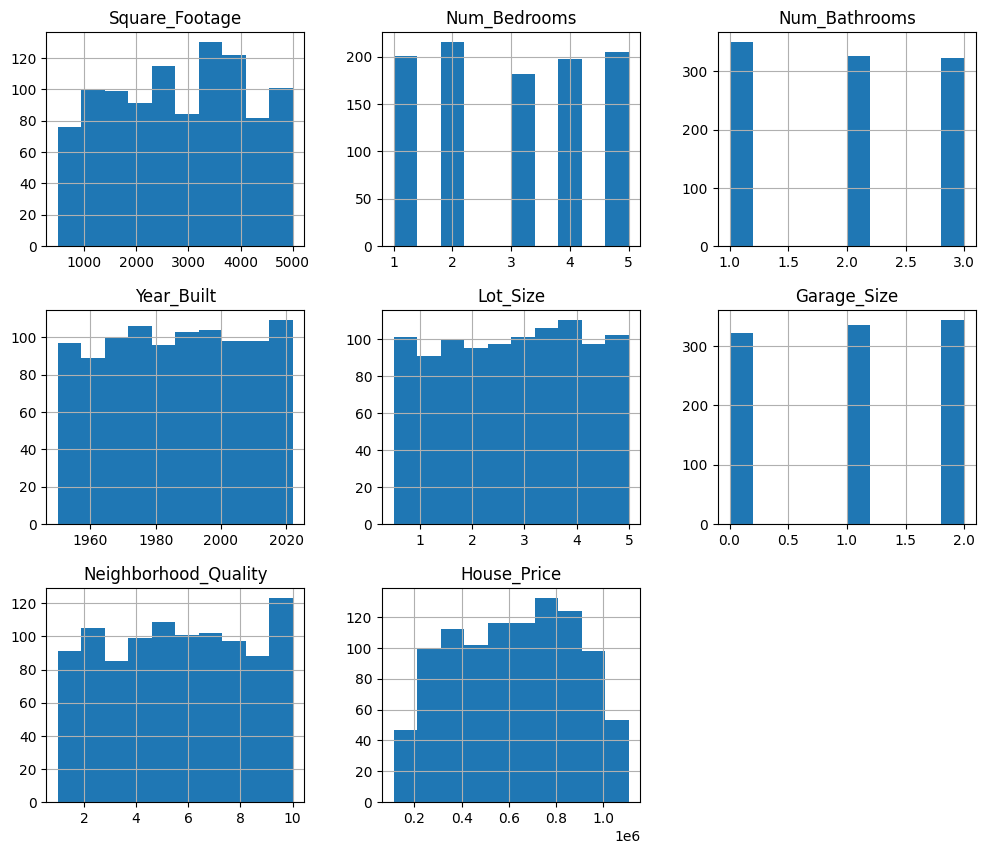

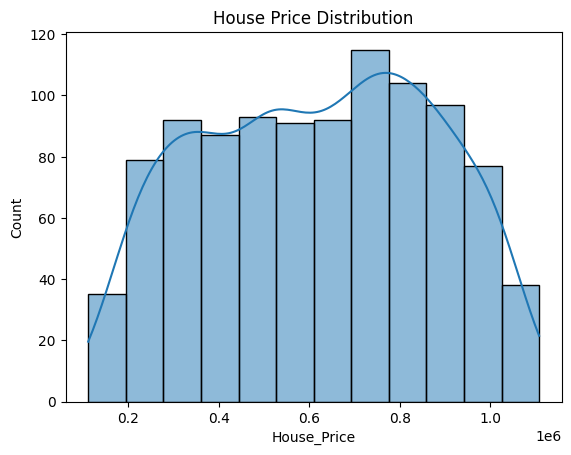

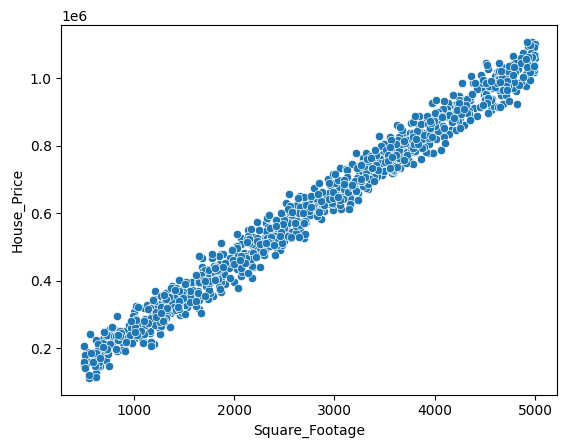

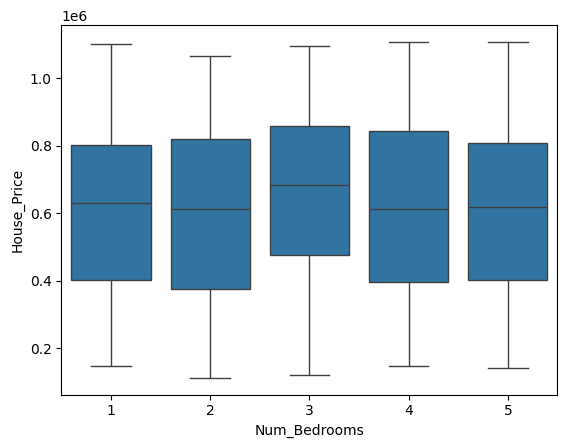

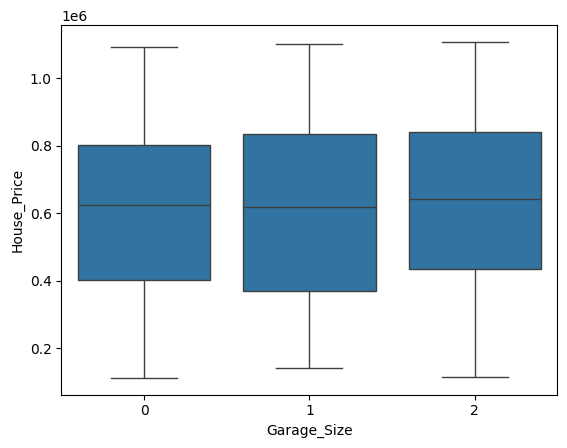

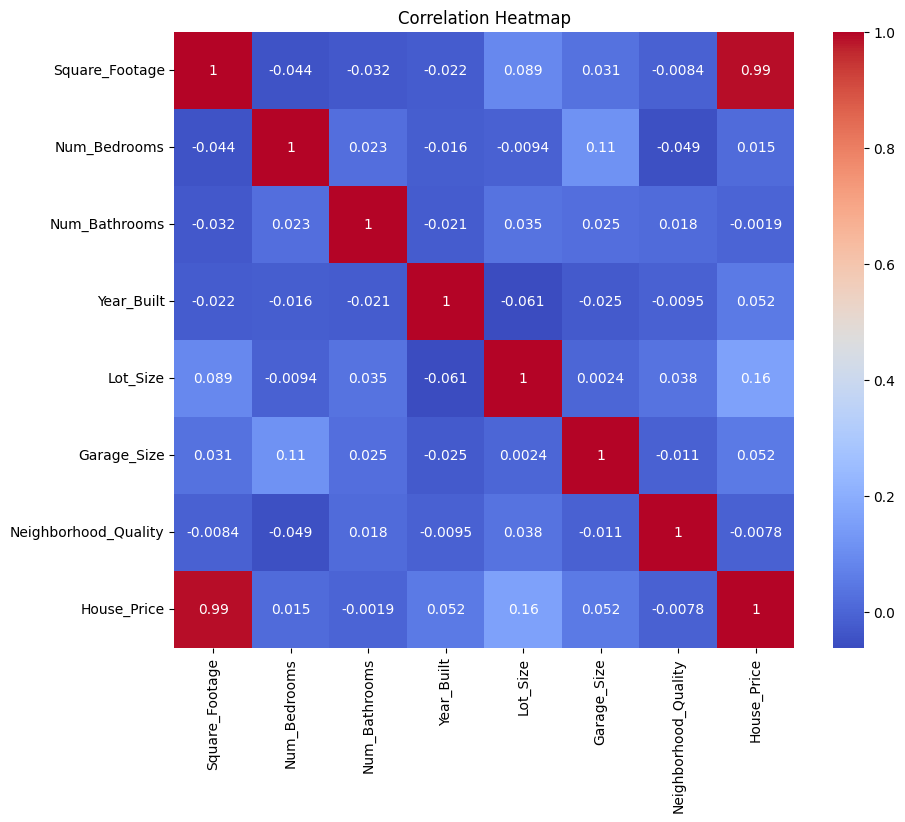

In [ ]:
df.hist(figsize=(12,10))
plt.show()

sns.histplot(df['House_Price'], kde=True)
plt.title("House Price Distribution")
plt.show()

sns.scatterplot(x='Square_Footage', y='House_Price', data=df)
plt.show()

sns.boxplot(x='Num_Bedrooms', y='House_Price', data=df)
plt.show()

sns.boxplot(x='Garage_Size', y='House_Price', data=df)
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

df['House_Price'] = np.log1p(df['House_Price'])

In [ ]:
X = df.drop('House_Price', axis=1)
y = df['House_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)


📊 Linear Regression
MAE: 0.09078250861533381
MSE: 0.012923008118806444
RMSE: 0.11367940938800854
MAPE: 0.6959836658331121
R2: 0.9462496095496568
Adjusted R2: 0.9442899598978214

📊 KNN Regression
MAE: 0.13352426424801353
MSE: 0.03275222800192383
RMSE: 0.18097576633882181
MAPE: 1.0316050644496357
R2: 0.8637743606567768
Adjusted R2: 0.8588078008890552


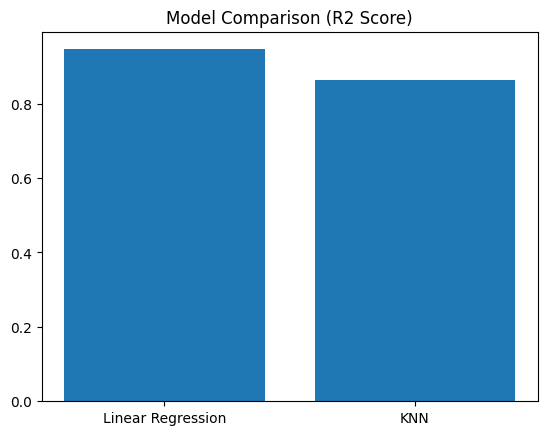

In [ ]:
def evaluate(y_test, y_pred, name):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)

    n = len(y_test)
    p = X_test.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    print(f"\n📊 {name}")
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("MAPE:", mape)
    print("R2:", r2)
    print("Adjusted R2:", adj_r2)
evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_knn, "KNN Regression")

models = ['Linear Regression', 'KNN']
scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_knn)
]

plt.bar(models, scores)
plt.title("Model Comparison (R2 Score)")
plt.show()